# API RAG QA Pipeline With Vision Captions

This notebook builds a RAG pipeline for the PDF-derived Markdown corpus and answers the questions in `qa_set.csv`.

This version uses a vision-capable model to create short retrieval captions for extracted PDF images. The captions are embedded for image retrieval; when relevant images are selected, the final QA call receives both the image captions and the image files themselves.

Design choices:

- Text chunks use `Snowflake/snowflake-arctic-embed-l-v2.0` embeddings.
- Image captions are generated by `moonshotai/Kimi-K2.5-SDSC`.
- Raw extracted image files are kept unchanged on disk.
- Before sending images to the API, a quality reducer creates a smaller in-memory JPEG data URL to reduce provider failures from oversized image payloads.
- The image caption prompt is intentionally concise and retrieval-oriented.
- It asks for the image's topic, figure/table title, variables, categories, and a few central values only.
- It explicitly avoids full chart/table transcription, because caption text is used for retrieval rather than final evidence extraction.

Retrieval settings:

- Chunk size: `250` words
- Chunk overlap: `50` words
- Text cosine similarity threshold: `0.50`
- Image caption cosine similarity threshold: `0.50`
- Maximum context chunks: `6`
- Maximum context images: `3`
- Vision caption cache: `image_caption_cache_vision.csv`


## 1. Install and Import Dependencies

In [ ]:
# Run this cell once in a fresh notebook environment.
%pip install -q openai python-dotenv pandas numpy tqdm pillow

In [ ]:
import base64
import csv
import hashlib
import io
import mimetypes
import json
import os
import re
import random
import sqlite3
import time
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
from dotenv import load_dotenv
from openai import OpenAI
from PIL import Image
from IPython.display import Image as IPythonImage, display
from tqdm.auto import tqdm

load_dotenv(dotenv_path="environment")

WORK_DIR = Path.cwd()
QA_CSV = WORK_DIR / "qa_set.csv"
OUTPUT_CSV = WORK_DIR / "qa_set_api_rag_answers.csv"
DB_PATH = WORK_DIR / "rag_api_embedding_database.sqlite"
EMBEDDING_CACHE_DB = WORK_DIR / "api_embedding_cache.sqlite"
QA_CACHE_CSV = WORK_DIR / "qa_answer_cache.csv"

EMBEDDED_QA_CSV = """question;answer
What year where there most casualties from man-made disasters in the recorded data?;2002. In that year more than 10,000 casualties are ascribed to man-made catastrophes.
In what year did the quantity of man-made disasters peak in the recorded data between 1970 and 2023?;Man-made disasters peaked in 2005
Between 1970 and 2023 what year in the data shows the largest number of natural catastrophes?;2023.  There were 218 instances of natural catastrophes.
What year between 1994 and 2023 had the most high severity ($5 billion in damages or more) natural catastrophes?;2011 with 6.
How much higher are the 2023 insured losses than the previous 10 year average?;They are higher by 21%.
Which figure shows the trend in insured losses over data from 1994 to 2023? In this figure, what is the highest insured loss year on record?;
Before 2023, what was the highest year on record for European Severe Convective Storm losses?;
What regions does the Swiss Re report on natural catastrophes split the US into for severe convective storm risk?;
What is the highest Benefit to Cost ratio building code element described in the Swiss Re report on natural catastrophes?;
According to the Swiss Re Institute report on natural catastrophes, 2017 was a standout year in terms of insured loss damages. What were the names of the weather events which contributed most to this figure?;
Given how the Swiss Re Institute classifies primary and secondary perils, to which category can we attribute more losses in 2023? How is insurance claim tracking characterized in this category?;
In historical data from the Swiss Re Institute, which geographical grouping of countries has the smallest proportion of insured losses to uninsured losses between 2014 and 2023?;
What is the lower bound of dead or missing which have to be reported in connection to a natural catastrophe in order for the Swiss Re data to report it in their statistics?;
Excluding the overall UN average, which group of nations have more than 100 mobile broadband subscriptions per 100 residents in 2024?;
According to survey data, which feature of government web-portals experienced the largest between 2022 and 2024?;
When were the simplified four stages of E-government adoption published? Which revision of the EGDI is this related to?;
Between what years was the EGDI revision 3.0 acive?;
Given when academic articles using the term started being published, when were the terms E-government development index and Online services index introduced?;
Of the questions highlighted from the Member States Questionnaire in a chart, is there a discontinuity in the numbering of the questions featured? If so, which numbers are missing?;
What was the percentage increase over all the 193 UN member states in EGDI scores between 2022 and 2024?;
Of the countries with very high OSI levels and high EGDI divergence what is the one with the lowest Telecommunications Infrasructure Index?;
What grouping of nations has the closest OSI subindex average to the overall UN 193 average?;
Why did the average number of provided online services increase while the percentage stayed the same between 2022 and 2024? How many services were assessed in each of the 2 years?;
What percentage of european countries support filing income tax online?;
In what percentage of countries in Oceania is one able to apply for a death certificate through a fully digitized process?;
What region of the world contains the countries that enable fully digitized vehicle regitration? What is the percentage of countries in this region that support this?;
In what percentage of countries in the Americas is one able to apply for disability compensation in at least a partially online manner?;
What number of countries in Africa support digital invoicing? What is the percentage increase in that figure since 2022?;
What number of countries in Europe offer an E-procurement platform? Not percentage, number of countries.;
What fully digital service for individuals in vulnerable situations experienced the largest percentge decline between 2022 and 2024?;
What service for individuals in vulnerable situations has no fully digitized component in Oceania?;
What proportion of countries offer judiciary services in a way that is accessible on mobile or through an app?;
What landlocked countries have moved from high to very high E-government development index in the survey period?;
What small island nation moved from the middle to the high EGDI group in the last survey period?;
How has Japan named their initiative for removing bureaucratic inefficiencies and improving their digital government tools? What is the project's initial budget?;
What two departments of the UK govenrment have been merged in the effort to enhance their digital transformation?;
What country grouping appears to have the most drastic difference between EGDI levels of it's constituents?;
What is the change in percentage of cities providing information on procurement between 2022 and 2024?;
In the year before the two investment segments equalized, what was the amount invested in energy transition power generation vs fossil fuel power generation?;
How many of the top 10 costliest environmental disasters of 2023 occurred in Latin America? Which country faced the msot expensive one?;
"""

CHUNK_WORDS = 250
OVERLAP_WORDS = 50
SIMILARITY_THRESHOLD = 0.50
MAX_CONTEXT_CHUNKS = 6
MIN_CONTEXT_CHUNKS = 3
IMAGE_SIMILARITY_THRESHOLD = 0.50
MAX_CONTEXT_IMAGES = 3
IMAGE_CONTEXT_WINDOW_CHARS = 1200
IMAGE_CAPTION_MAX_TOKENS = 220
IMAGE_CAPTION_CACHE = WORK_DIR / "image_caption_cache_vision.csv"
MIN_IMAGE_WIDTH = 120
MIN_IMAGE_HEIGHT = 80
IMAGE_REDUCER_ENABLED = True
IMAGE_REDUCER_MAX_SIDE = 1200
IMAGE_REDUCER_JPEG_QUALITY = 10

API_BASE_URL = "https://api.swissai.svc.cscs.ch/v1"
EMBEDDING_MODEL = "Snowflake/snowflake-arctic-embed-l-v2.0"
MODEL_NAME = "moonshotai/Kimi-K2.5-SDSC"  # Strongest model listed in the API example.
# Fast alternative: "zai-org/GLM-4.7-Flash"
# Open model alternatives: "swiss-ai/Apertus-8B-Instruct-2509", "swiss-ai/Apertus-70B-Instruct-2509"

client = OpenAI(
    base_url=API_BASE_URL,
    api_key=os.getenv("CSCS_API_KEY"),
)
client_cscs = client

if not QA_CSV.exists():
    QA_CSV.write_text(EMBEDDED_QA_CSV, encoding="utf-8")
    print("qa_set.csv was missing, so the embedded QA set was written to:", QA_CSV)

print("Working directory:", WORK_DIR)
print("qa_set.csv exists:", QA_CSV.exists())
print("API key configured:", bool(os.getenv("CSCS_API_KEY")))

## 2. Load Markdown Corpus

In [ ]:
IMAGE_PATTERN = re.compile(r"!\[[^\]]*\]\([^)]+\)")
WORD_PATTERN = re.compile(r"\S+")


def clean_markdown(text: str) -> str:
    text = IMAGE_PATTERN.sub(" ", text)
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    text = re.sub(r"<br\s*/?>", "\n", text, flags=re.IGNORECASE)
    text = re.sub(r"[ \t]+", " ", text)
    return text


markdown_files = sorted(
    path for path in WORK_DIR.glob("*.md")
    if path.name.lower() not in {"readme.md"}
)

if not markdown_files:
    raise FileNotFoundError(
        "No .md files found. Put the PDF-derived Markdown files in the same folder as this notebook."
    )

print(f"Found {len(markdown_files)} Markdown files:")
for path in markdown_files:
    print("-", path.name)

## 3. Chunk the Corpus

In [ ]:
@dataclass(frozen=True)
class Chunk:
    chunk_id: int
    source: str
    chunk_index: int
    start_word: int
    end_word: int
    text: str


def chunk_text(source: str, text: str, chunk_words: int, overlap_words: int, start_id: int) -> list[Chunk]:
    if overlap_words >= chunk_words:
        raise ValueError("Overlap must be smaller than chunk size.")

    words = WORD_PATTERN.findall(clean_markdown(text))
    if not words:
        return []

    chunks = []
    step = chunk_words - overlap_words
    for chunk_index, start in enumerate(range(0, len(words), step)):
        end = min(start + chunk_words, len(words))
        chunks.append(
            Chunk(
                chunk_id=start_id + len(chunks),
                source=source,
                chunk_index=chunk_index,
                start_word=start,
                end_word=end,
                text=" ".join(words[start:end]),
            )
        )
        if end == len(words):
            break
    return chunks


chunks: list[Chunk] = []
next_id = 1
for md_path in markdown_files:
    text = md_path.read_text(encoding="utf-8", errors="replace")
    file_chunks = chunk_text(md_path.name, text, CHUNK_WORDS, OVERLAP_WORDS, next_id)
    chunks.extend(file_chunks)
    next_id += len(file_chunks)

print(f"Created {len(chunks)} chunks.")
pd.DataFrame([c.__dict__ for c in chunks[:5]])

## 4. Build API Embeddings and Save the RAG Database

In [4]:
def embedding_cache_key(text: str, model: str = EMBEDDING_MODEL) -> str:
    payload = f"{model}\n{text}".encode("utf-8")
    return hashlib.sha256(payload).hexdigest()


def init_embedding_cache(path: Path = EMBEDDING_CACHE_DB) -> None:
    conn = sqlite3.connect(path)
    try:
        conn.execute(
            """
            CREATE TABLE IF NOT EXISTS embedding_cache (
                cache_key TEXT PRIMARY KEY,
                model TEXT NOT NULL,
                text_hash TEXT NOT NULL,
                embedding BLOB NOT NULL,
                created_at TEXT DEFAULT CURRENT_TIMESTAMP
            )
            """
        )
        conn.commit()
    finally:
        conn.close()


def load_cached_embedding(text: str, model: str = EMBEDDING_MODEL) -> np.ndarray | None:
    init_embedding_cache()
    key = embedding_cache_key(text, model)
    conn = sqlite3.connect(EMBEDDING_CACHE_DB)
    try:
        row = conn.execute(
            "SELECT embedding FROM embedding_cache WHERE cache_key = ?",
            (key,),
        ).fetchone()
    finally:
        conn.close()
    if row is None:
        return None
    return np.frombuffer(row[0], dtype=np.float32).copy()


def save_cached_embedding(text: str, vector: np.ndarray, model: str = EMBEDDING_MODEL) -> None:
    init_embedding_cache()
    key = embedding_cache_key(text, model)
    text_hash = hashlib.sha256(text.encode("utf-8")).hexdigest()
    vector = np.asarray(vector, dtype=np.float32)
    conn = sqlite3.connect(EMBEDDING_CACHE_DB)
    try:
        conn.execute(
            """
            INSERT OR REPLACE INTO embedding_cache (cache_key, model, text_hash, embedding)
            VALUES (?, ?, ?, ?)
            """,
            (key, model, text_hash, vector.tobytes()),
        )
        conn.commit()
    finally:
        conn.close()


def embed_text_uncached(text: str, model: str = EMBEDDING_MODEL) -> list[float]:
    response = client.embeddings.create(
        model=model,
        input=text,
    )
    return response.data[0].embedding


def embed_text(text: str, model: str = EMBEDDING_MODEL) -> list[float]:
    cached = load_cached_embedding(text, model=model)
    if cached is not None:
        return cached.tolist()
    vector = np.asarray(embed_text_uncached(text, model=model), dtype=np.float32)
    save_cached_embedding(text, vector, model=model)
    return vector.tolist()


def embed_texts(texts: list[str], model: str = EMBEDDING_MODEL, batch_size: int = 16) -> np.ndarray:
    init_embedding_cache()
    vectors: list[np.ndarray | None] = [None] * len(texts)
    missing_indices = []
    missing_texts = []

    for idx, text in enumerate(texts):
        cached = load_cached_embedding(text, model=model)
        if cached is None:
            missing_indices.append(idx)
            missing_texts.append(text)
        else:
            vectors[idx] = cached

    print(f"Embedding cache hits: {len(texts) - len(missing_texts)} / {len(texts)}")

    for start in tqdm(range(0, len(missing_texts), batch_size), desc="Embedding uncached texts"):
        batch_texts = missing_texts[start : start + batch_size]
        batch_indices = missing_indices[start : start + batch_size]
        try:
            response = client.embeddings.create(
                model=model,
                input=batch_texts,
            )
            batch_vectors = [np.asarray(item.embedding, dtype=np.float32) for item in response.data]
        except Exception:
            # Some OpenAI-compatible embedding endpoints only accept one input at a time.
            batch_vectors = [
                np.asarray(embed_text_uncached(text, model=model), dtype=np.float32)
                for text in batch_texts
            ]

        for idx, text, vector in zip(batch_indices, batch_texts, batch_vectors):
            save_cached_embedding(text, vector, model=model)
            vectors[idx] = vector

    matrix = np.vstack([np.asarray(vector, dtype=np.float32) for vector in vectors])
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    return matrix / np.clip(norms, 1e-12, None)


if not os.getenv("CSCS_API_KEY"):
    raise RuntimeError("Set CSCS_API_KEY before creating API embeddings.")

chunk_texts = [chunk.text for chunk in chunks]
chunk_matrix = embed_texts(chunk_texts, batch_size=16)

print("Embedding model:", EMBEDDING_MODEL)
print("Embedding matrix shape:", chunk_matrix.shape)
print("Embedding cache:", EMBEDDING_CACHE_DB)

Embedding cache hits: 1044 / 1044


Embedding uncached texts: 0it [00:00, ?it/s]

Embedding model: Snowflake/snowflake-arctic-embed-l-v2.0
Embedding matrix shape: (1044, 1024)
Embedding cache: /home/renku/work/vision_caption_rag_package/api_embedding_cache.sqlite


In [5]:
def save_database(db_path: Path) -> None:
    if db_path.exists():
        db_path.unlink()

    conn = sqlite3.connect(db_path)
    try:
        conn.executescript(
            """
            CREATE TABLE metadata (
                key TEXT PRIMARY KEY,
                value TEXT NOT NULL
            );

            CREATE TABLE chunks (
                id INTEGER PRIMARY KEY,
                source TEXT NOT NULL,
                chunk_index INTEGER NOT NULL,
                start_word INTEGER NOT NULL,
                end_word INTEGER NOT NULL,
                text TEXT NOT NULL,
                embedding BLOB NOT NULL
            );

            CREATE INDEX idx_chunks_source ON chunks(source);
            """
        )
        metadata = {
            "created_at": time.strftime("%Y-%m-%d %H:%M:%S"),
            "chunk_words": CHUNK_WORDS,
            "overlap_words": OVERLAP_WORDS,
            "similarity_threshold": SIMILARITY_THRESHOLD,
            "max_context_chunks": MAX_CONTEXT_CHUNKS,
            "min_context_chunks": MIN_CONTEXT_CHUNKS,
            "embedding_backend": EMBEDDING_MODEL,
            "embedding_dimension": int(chunk_matrix.shape[1]),
            "chunk_count": len(chunks),
            "sources": sorted({chunk.source for chunk in chunks}),
        }
        conn.execute(
            "INSERT INTO metadata(key, value) VALUES (?, ?)",
            ("index", json.dumps(metadata, indent=2)),
        )
        conn.executemany(
            """
            INSERT INTO chunks(id, source, chunk_index, start_word, end_word, text, embedding)
            VALUES (?, ?, ?, ?, ?, ?, ?)
            """,
            [
                (
                    chunk.chunk_id,
                    chunk.source,
                    chunk.chunk_index,
                    chunk.start_word,
                    chunk.end_word,
                    chunk.text,
                    chunk_matrix[row].astype(np.float32).tobytes(),
                )
                for row, chunk in enumerate(chunks)
            ],
        )
        conn.commit()
    finally:
        conn.close()


save_database(DB_PATH)
print("Saved database:", DB_PATH)

Saved database: /home/renku/work/vision_caption_rag_package/rag_api_embedding_database.sqlite


## 5. Retrieval With Cosine Similarity Threshold

In [6]:
def retrieve_chunks(
    question: str,
    threshold: float = SIMILARITY_THRESHOLD,
    max_chunks: int = MAX_CONTEXT_CHUNKS,
    min_chunks: int = MIN_CONTEXT_CHUNKS,
) -> list[dict]:
    query_vector = np.asarray(embed_text(question), dtype=np.float32)
    query_vector = query_vector / max(float(np.linalg.norm(query_vector)), 1e-12)
    scores = chunk_matrix @ query_vector
    ranked_indices = np.argsort(scores)[::-1]

    selected = [
        {
            "chunk_id": chunks[i].chunk_id,
            "source": chunks[i].source,
            "chunk_index": chunks[i].chunk_index,
            "score": float(scores[i]),
            "text": chunks[i].text,
        }
        for i in ranked_indices
        if scores[i] >= threshold
    ][:max_chunks]

    # Fallback: if the threshold is too strict for a short/narrow question,
    # still provide the best few chunks so the model can answer or say not found.
    if len(selected) < min_chunks:
        fallback = [
            {
                "chunk_id": chunks[i].chunk_id,
                "source": chunks[i].source,
                "chunk_index": chunks[i].chunk_index,
                "score": float(scores[i]),
                "text": chunks[i].text,
            }
            for i in ranked_indices[:min_chunks]
        ]
        seen = {item["chunk_id"] for item in selected}
        selected.extend(item for item in fallback if item["chunk_id"] not in seen)

    return selected[:max_chunks]


sample_question = "How much higher are the 2023 insured losses than the previous 10 year average?"
sample_chunks = retrieve_chunks(sample_question)
[(c["score"], c["source"], c["chunk_index"]) for c in sample_chunks]

[(0.6496871709823608, 'swissre_sigma-1_2024_english.md', 12),
 (0.632580041885376, 'swissre_sigma-1_2024_english.md', 19),
 (0.6285090446472168, 'swissre_sigma-1_2024_english.md', 25),
 (0.6272820234298706, 'natural-catastrophe-and-climate-report-2023.md', 25),
 (0.6262193918228149, 'natural-catastrophe-and-climate-report-2023.md', 21),
 (0.6144300103187561, 'swissre_sigma-1_2024_english.md', 20)]

## 6. Build Image Context Embeddings and Retrieval

Images found: 477
/home/renku/work/vision_caption_rag_package/Web_Version__E-Government_Survey_2024_11102024_images/Web_Version__E-Government_Survey_2024_11102024.pdf-0120-08.png
Original bytes: 13,159
Reduced bytes:  4,301
Reduced mime:   image/jpeg
Reduced data URL length: 5,759
Original image:


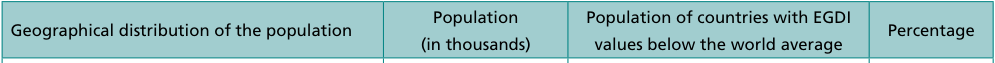

Reduced image sent to API:


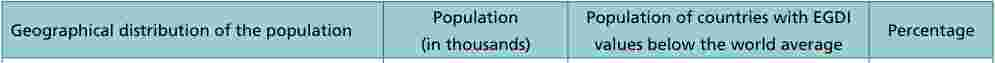

Caption: 'The image shows a **table header row** with four columns against a teal/light blue-green background. The column headers are:\n\n1. **"Geographical distribution of the population"** - appears to be the main category or grouping variable\n2. **"Population (in thousands)"** - indicating population figures measured in thousands\n3. **"Population of countries with EGDI values below the world average"** - referring to the subset of population living in countries with E-Government Development Index (EGDI) scores below the global average\n4. **"Percentage"** - likely showing the proportion or percentage calculation\n\nThe text is displayed in a dark font (black or dark gray) within colored cells. This appears to be from a statistical table, probably related to digital government development or e-government statistics, comparing population distributions across different regions or categories relative to EGDI performance.'


In [7]:
def reduce_image_for_api(image_data: bytes, mime: str) -> tuple[bytes, str]:
    """Reduce image payload size before sending to the vision API."""
    if not IMAGE_REDUCER_ENABLED:
        return image_data, mime

    try:
        with Image.open(io.BytesIO(image_data)) as img:
            original_width, original_height = img.size
            scale = min(1.0, IMAGE_REDUCER_MAX_SIDE / max(original_width, original_height))
            if scale < 1.0:
                new_size = (
                    max(1, int(original_width * scale)),
                    max(1, int(original_height * scale)),
                )
                img = img.resize(new_size)

            if img.mode in ("RGBA", "LA"):
                background = Image.new("RGB", img.size, "white")
                background.paste(img, mask=img.getchannel("A"))
                img = background
            else:
                img = img.convert("RGB")

            buffer = io.BytesIO()
            img.save(buffer, format="JPEG", quality=IMAGE_REDUCER_JPEG_QUALITY, optimize=True)
            reduced = buffer.getvalue()
            return reduced, "image/jpeg"
    except Exception as exc:
        print(f"Image reducer skipped this image: {exc}")
        return image_data, mime


def reduce_image_file_for_api(path: str | Path) -> tuple[bytes, str]:
    path = Path(path)
    mime = mimetypes.guess_type(path.name)[0] or "image/png"
    image_data = path.read_bytes()
    return reduce_image_for_api(image_data, mime)


def encode_image_from_url(url: str | Path) -> str:
    """Encode either a web image URL or a local image path as a data URL."""
    url = str(url)
    if url.startswith(("http://", "https://")):
        r = requests.get(url)
        r.raise_for_status()
        mime = r.headers.get("content-type", "image/svg+xml").split(";")[0]
        image_data = r.content if mime != "image/svg+xml" else cairosvg.svg2png(bytestring=r.content)
        if mime == "image/svg+xml":
            mime = "image/png"
    else:
        path = Path(url)
        mime = mimetypes.guess_type(path.name)[0] or "image/png"
        image_data = path.read_bytes()
    image_data, mime = reduce_image_for_api(image_data, mime)
    data = base64.b64encode(image_data).decode("utf-8")
    return f"data:{mime};base64,{data}"


def encode_image_from_file(path: str | Path) -> str:
    return encode_image_from_url(path)


def normalize_image(image_path: str | Path) -> dict | None:
    """Return original image metadata without resizing or compressing the file."""
    image_path = Path(image_path)
    try:
        with Image.open(image_path) as img:
            original_width, original_height = img.size
            if original_width < MIN_IMAGE_WIDTH or original_height < MIN_IMAGE_HEIGHT:
                return None

        mime_type = mimetypes.guess_type(image_path.name)[0] or "image/png"

        return {
            "image_path": str(image_path),
            "normalized_image_path": str(image_path),
            "original_width": original_width,
            "original_height": original_height,
            "normalized_width": original_width,
            "normalized_height": original_height,
            "mime_type": mime_type,
            "file_size": image_path.stat().st_size,
        }
    except Exception as exc:
        print(f"Skipping unreadable image {image_path}: {exc}")
        return None


def extract_text_from_value(value) -> str:
    """Extract text from OpenAI-compatible response objects, dicts, lists, or strings."""
    if value is None:
        return ""
    if isinstance(value, str):
        return value.strip()
    if isinstance(value, list):
        pieces = [extract_text_from_value(item) for item in value]
        return "\n".join(piece for piece in pieces if piece).strip()
    if isinstance(value, dict):
        for key in ("text", "content", "output_text", "reasoning_content", "refusal"):
            text = extract_text_from_value(value.get(key))
            if text:
                return text
        return ""
    if hasattr(value, "model_dump"):
        return extract_text_from_value(value.model_dump())
    for attr in ("text", "content", "output_text", "reasoning_content", "refusal"):
        text = extract_text_from_value(getattr(value, attr, None))
        if text:
            return text
    return ""


def extract_chat_completion_text(response) -> str:
    """Extract assistant text from chat.completions responses across provider variants."""
    for choice in getattr(response, "choices", []) or []:
        for attr in ("message", "text", "delta"):
            text = extract_text_from_value(getattr(choice, attr, None))
            if text:
                return text
        if hasattr(choice, "model_dump"):
            text = extract_text_from_value(choice.model_dump())
            if text:
                return text
    return extract_text_from_value(response)


VISION_CAPTION_PROMPT = "Describe what is in this image."


BAD_CAPTION_MARKERS = (
    "name 'extract_chat_message_text' is not defined",
    "not found in the retrieved context",
    "vision caption unavailable",
    "error:",
)


def is_valid_caption(caption: str) -> bool:
    cleaned = (caption or "").strip()
    if not cleaned:
        return False
    lowered = cleaned.lower()
    return not any(marker in lowered for marker in BAD_CAPTION_MARKERS)


def ask_with_image(prompt: str, image_path: str | Path, model: str = MODEL_NAME) -> str:
    """Same calling pattern as the CSCS image example, with local-path support."""
    encoded_image = encode_image_from_url(image_path)
    response = client_cscs.chat.completions.create(
        model=model,
        messages=[
            {"role": "user", "content": [
                {"type": "text", "text": prompt},
                {"type": "image_url", "image_url": {"url": encoded_image}},
            ]},
        ],
        temperature=0.5,
    )
    caption = response.choices[0].message.content
    if caption and caption.strip():
        return caption.strip()
    return extract_chat_completion_text(response)


def describe_image(image_path: str | Path, model: str = MODEL_NAME) -> str:
    last_error = None

    for attempt in range(3):
        try:
            caption = ask_with_image(VISION_CAPTION_PROMPT, image_path, model=model)
            if not is_valid_caption(caption):
                raise ValueError(f"Invalid empty/error caption returned: {caption!r}")
            return caption
        except Exception as exc:
            last_error = exc
            wait_seconds = 5 * (attempt + 1)
            print(f"Vision caption failed for {image_path} on attempt {attempt + 1}/3: {exc}")
            time.sleep(wait_seconds)

    raise RuntimeError(f"Vision caption unavailable after retries for {Path(image_path).name}: {last_error}")


image_files = sorted(
    list(WORK_DIR.rglob("*_images/*.png")) +
    list(WORK_DIR.rglob("*_images/*.jpg")) +
    list(WORK_DIR.rglob("*_images/*.jpeg"))
)

print("Images found:", len(image_files))
image_files[:5]


# Random vision smoke test.
# Run this before building the full image index. It helps distinguish image/API problems from batch pipeline problems.
RUN_RANDOM_IMAGE_TEST = True
RANDOM_IMAGE_TEST_COUNT = 1

if RUN_RANDOM_IMAGE_TEST and image_files:
    sample_images = random.sample(image_files, min(RANDOM_IMAGE_TEST_COUNT, len(image_files)))
    for image_path in sample_images:
        print("=" * 100)
        print(image_path)
        original_bytes = Path(image_path).read_bytes()
        reduced_bytes, reduced_mime = reduce_image_file_for_api(image_path)
        reduced_data_url_length = len(
            "data:" + reduced_mime + ";base64," + base64.b64encode(reduced_bytes).decode("utf-8")
        )
        print(f"Original bytes: {len(original_bytes):,}")
        print(f"Reduced bytes:  {len(reduced_bytes):,}")
        print(f"Reduced mime:   {reduced_mime}")
        print(f"Reduced data URL length: {reduced_data_url_length:,}")
        print("Original image:")
        display(IPythonImage(filename=str(image_path), width=520))
        print("Reduced image sent to API:")
        display(IPythonImage(data=reduced_bytes, width=520))
        try:
            caption = ask_with_image(
                "Describe what is in this image.",
                image_path,
            )
            print("Caption:", repr(caption))
        except Exception as exc:
            print("Error:", repr(exc))

In [13]:
def load_caption_cache(path: Path) -> dict[str, str]:
    if not path.exists():
        return {}
    df = pd.read_csv(path, keep_default_na=False)
    if "image_path" not in df.columns or "caption" not in df.columns:
        return {}
    cache = dict(zip(df["image_path"], df["caption"]))
    return {image_path: caption for image_path, caption in cache.items() if is_valid_caption(caption)}


def save_caption_cache(path: Path, cache: dict[str, str]) -> None:
    pd.DataFrame(
        [{"image_path": image_path, "caption": caption} for image_path, caption in cache.items()]
    ).to_csv(path, index=False)


def build_image_records(image_paths: list[Path]) -> tuple[list[dict], np.ndarray]:
    """Create image records using vision captions, then embed those captions."""
    caption_cache = load_caption_cache(IMAGE_CAPTION_CACHE)
    records = []
    embeddings = []

    for image_path in tqdm(image_paths[:244], desc="Reading, vision-captioning, and embedding images"):
        image_meta = normalize_image(image_path)
        if image_meta is None:
            continue

        image_key = image_meta["normalized_image_path"]
        if image_key in caption_cache and caption_cache[image_key].strip():
            caption = caption_cache[image_key]
        else:
            try:
                caption = describe_image(image_meta["normalized_image_path"])
            except Exception as exc:
                print(f"Skipping image after caption failure: {image_path} ({exc})")
                continue
            caption_cache[image_key] = caption
            save_caption_cache(IMAGE_CAPTION_CACHE, caption_cache)

        vector = np.asarray(embed_text(caption), dtype=np.float32)
        vector = vector / max(float(np.linalg.norm(vector)), 1e-12)

        records.append(
            {
                "image_id": len(records) + 1,
                **image_meta,
                "caption": caption,
            }
        )
        embeddings.append(vector)

    if embeddings:
        return records, np.vstack(embeddings).astype(np.float32)
    return records, np.empty((0, chunk_matrix.shape[1]), dtype=np.float32)


# Vision-captioning all extracted images can take time and API budget.
# Set IMAGE_INDEX_LIMIT = 50 while testing, then switch to None for the full index.
IMAGE_INDEX_LIMIT = None
image_records, image_matrix = build_image_records(
    image_files if IMAGE_INDEX_LIMIT is None else image_files[:IMAGE_INDEX_LIMIT]
)

print("Image records:", len(image_records))
pd.DataFrame(image_records[:5])

Reading, vision-captioning, and embedding images: 100%|██████████| 244/244 [00:00<00:00, 2905.07it/s]

Image records: 221


,image_id,image_path,normalized_image_path,original_width,original_height,normalized_width,normalized_height,mime_type,file_size,caption
0,1,/home/renku/work/vision_caption_rag_package/We...,/home/renku/work/vision_caption_rag_package/We...,371,523,371,523,image/png,281296,This image appears to be a **digital composite...
1,2,/home/renku/work/vision_caption_rag_package/We...,/home/renku/work/vision_caption_rag_package/We...,372,474,372,474,image/png,286771,The image is a digital graphic with a **techno...
2,3,/home/renku/work/vision_caption_rag_package/We...,/home/renku/work/vision_caption_rag_package/We...,371,521,371,521,image/png,329327,The image depicts a **close-up of a hand** (sh...
3,4,/home/renku/work/vision_caption_rag_package/We...,/home/renku/work/vision_caption_rag_package/We...,297,347,297,347,image/png,87360,The image is a digital graphic with a technolo...
4,5,/home/renku/work/vision_caption_rag_package/We...,/home/renku/work/vision_caption_rag_package/We...,372,223,372,223,image/png,117716,The image features a **technology-themed graph...


In [14]:
def save_image_records(db_path: Path) -> None:
    conn = sqlite3.connect(db_path)
    try:
        conn.executescript(
            """
            DROP TABLE IF EXISTS images;

            CREATE TABLE images (
                id INTEGER PRIMARY KEY,
                image_path TEXT NOT NULL,
                normalized_image_path TEXT NOT NULL,
                original_width INTEGER,
                original_height INTEGER,
                normalized_width INTEGER,
                normalized_height INTEGER,
                mime_type TEXT,
                file_size INTEGER,
                caption TEXT NOT NULL,
                embedding BLOB NOT NULL
            );

            CREATE INDEX idx_images_path ON images(image_path);
            CREATE INDEX idx_images_normalized_path ON images(normalized_image_path);
            """
        )
        conn.executemany(
            """
            INSERT INTO images(
                id,
                image_path,
                normalized_image_path,
                original_width,
                original_height,
                normalized_width,
                normalized_height,
                mime_type,
                file_size,
                caption,
                embedding
            )
            VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
            """,
            [
                (
                    record["image_id"],
                    record["image_path"],
                    record["normalized_image_path"],
                    record["original_width"],
                    record["original_height"],
                    record["normalized_width"],
                    record["normalized_height"],
                    record["mime_type"],
                    record["file_size"],
                    record["caption"],
                    image_matrix[row].astype(np.float32).tobytes(),
                )
                for row, record in enumerate(image_records)
            ],
        )
        conn.commit()
    finally:
        conn.close()


save_image_records(DB_PATH)
print("Saved image records to:", DB_PATH)

Saved image records to: /home/renku/work/vision_caption_rag_package/rag_api_embedding_database.sqlite


In [16]:
def retrieve_images(
    question: str,
    threshold: float = IMAGE_SIMILARITY_THRESHOLD,
    max_images: int = MAX_CONTEXT_IMAGES,
) -> list[dict]:
    if len(image_records) == 0:
        return []

    query_vector = np.asarray(embed_text(question), dtype=np.float32)
    query_vector = query_vector / max(float(np.linalg.norm(query_vector)), 1e-12)
    scores = image_matrix @ query_vector
    ranked_indices = np.argsort(scores)[::-1]

    selected = []
    for index in ranked_indices:
        score = float(scores[index])
        if score < threshold:
            continue

        record = dict(image_records[int(index)])
        record["score"] = score
        selected.append(record)

        if len(selected) >= max_images:
            break

    return selected


sample_images = retrieve_images(sample_question)
[(img["score"], img["image_path"], img["caption"][:120]) for img in sample_images]

[]

## 6. API Answer Generation

In [17]:
SYSTEM_PROMPT = """You are a careful multimodal RAG question-answering assistant.
Use only the supplied text context, retrieved image descriptions, and attached images.
Answer concisely, preferably in one or two sentences.
First look for a direct answer. If the answer requires simple arithmetic from numbers in the context, do the calculation and say it is inferred.
When relevant, include exact years, percentages, counts, names, or figure numbers.
If the supplied text, image descriptions, and attached images do not contain enough evidence, write exactly: Not found in the retrieved context.
Do not use outside knowledge. Do not invent facts.
"""


def format_context(retrieved: list[dict]) -> str:
    parts = []
    for i, chunk in enumerate(retrieved, start=1):
        text = chunk["text"]
        parts.append(
            f"[Context {i}] source={chunk['source']} chunk={chunk['chunk_index']} cosine={chunk['score']:.3f}\n{text}"
        )
    return "\n\n".join(parts)


def format_image_context(retrieved_images: list[dict]) -> str:
    if not retrieved_images:
        return "No relevant images retrieved above the cosine threshold."
    return "\n\n".join(
        f"[Image {i}] path={image['image_path']} cosine={image['score']:.3f}\n{image['caption']}"
        for i, image in enumerate(retrieved_images, start=1)
    )


def encode_image_from_file(path: str | Path) -> str:
    return encode_image_from_url(path)


def extract_chat_message_text(message) -> str:
    """Handle OpenAI-compatible servers that do not always use message.content."""
    content = getattr(message, "content", None)
    if isinstance(content, str) and content.strip():
        return content.strip()
    if isinstance(content, list):
        pieces = []
        for item in content:
            if isinstance(item, dict):
                pieces.append(str(item.get("text") or item.get("content") or ""))
            else:
                pieces.append(str(getattr(item, "text", "") or getattr(item, "content", "")))
        joined = "\n".join(piece for piece in pieces if piece.strip()).strip()
        if joined:
            return joined

    data = message.model_dump() if hasattr(message, "model_dump") else {}
    for key in ("reasoning_content", "reasoning", "output_text", "refusal"):
        value = data.get(key)
        if isinstance(value, str) and value.strip():
            return value.strip()
        if isinstance(value, dict):
            text = value.get("text") or value.get("content")
            if isinstance(text, str) and text.strip():
                return text.strip()

    return "Not found in the retrieved context."


def answer_question(
    question: str,
    retrieved: list[dict] | None = None,
    retrieved_images: list[dict] | None = None,
    model: str = MODEL_NAME,
) -> tuple[str, list[dict], list[dict]]:
    if retrieved is None:
        retrieved = retrieve_chunks(question)
    if retrieved_images is None:
        retrieved_images = retrieve_images(question)

    context = format_context(retrieved)
    image_context = format_image_context(retrieved_images)
    user_text = f"""Text context:
{context}

Retrieved image descriptions:
{image_context}

Question:
{question}

Answer:
"""
    content = [{"type": "text", "text": user_text}]
    for image in retrieved_images:
        content.append(
            {
                "type": "image_url",
                "image_url": {"url": encode_image_from_file(image.get("normalized_image_path", image["image_path"]))},
            }
        )

    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": content},
        ],
        temperature=0.0,
    )
    return extract_chat_message_text(response.choices[0].message), retrieved, retrieved_images

In [18]:
# Single-question test.
# This cell requires CSCS_API_KEY to be configured.

if not os.getenv("CSCS_API_KEY"):
    print("Set CSCS_API_KEY before running API calls.")
else:
    evidence = retrieve_chunks(sample_question)
    image_evidence = retrieve_images(sample_question)
    answer, evidence, image_evidence = answer_question(sample_question, evidence, image_evidence)
    print("Question:", sample_question)
    print("Answer:", answer)
    print("Text evidence:")
    for item in evidence:
        print(f"- {item['source']}#{item['chunk_index']} cosine={item['score']:.3f}")
    print("Image evidence:")
    for item in image_evidence:
        print(f"- {item['image_path']} cosine={item['score']:.3f}")

Question: How much higher are the 2023 insured losses than the previous 10 year average?
Answer: USD 19 billion (inferred: 2023 insured losses were USD 108 billion vs. the previous 10-year average of USD 89 billion), or 21% higher.
Text evidence:
- swissre_sigma-1_2024_english.md#12 cosine=0.650
- swissre_sigma-1_2024_english.md#19 cosine=0.633
- swissre_sigma-1_2024_english.md#25 cosine=0.629
- natural-catastrophe-and-climate-report-2023.md#25 cosine=0.627
- natural-catastrophe-and-climate-report-2023.md#21 cosine=0.626
- swissre_sigma-1_2024_english.md#20 cosine=0.614
Image evidence:


## 7. Load QA CSV

In [19]:
def read_qa_set(path: Path) -> pd.DataFrame:
    # qa_set.csv uses semicolons: question;answer
    df = pd.read_csv(path, sep=";", keep_default_na=False)
    if "question" not in df.columns:
        raise ValueError("qa_set.csv must contain a 'question' column.")
    if "answer" not in df.columns:
        df["answer"] = ""
    df["question"] = df["question"].astype(str).str.strip()
    df["answer"] = df["answer"].astype(str).str.strip()
    return df[df["question"] != ""].reset_index(drop=True)


qa_df = read_qa_set(QA_CSV)
print("Questions:", len(qa_df))
print("Existing answers:", int((qa_df["answer"] != "").sum()))
qa_df.head()

Questions: 40
Existing answers: 5


,question,answer
0,What year where there most casualties from man...,"2002. In that year more than 10,000 casualties..."
1,In what year did the quantity of man-made disa...,Man-made disasters peaked in 2005
2,Between 1970 and 2023 what year in the data sh...,2023. There were 218 instances of natural cat...
3,What year between 1994 and 2023 had the most h...,2011 with 6.
4,How much higher are the 2023 insured losses th...,They are higher by 21%.


## 8. Answer All Questions

In [ ]:
def qa_cache_key(question: str, retrieved: list[dict], retrieved_images: list[dict], model: str = MODEL_NAME) -> str:
    chunk_ids = ",".join(str(item["chunk_id"]) for item in retrieved)
    image_ids = ",".join(str(item["image_id"]) for item in retrieved_images)
    payload = f"{model}\n{question}\nchunks={chunk_ids}\nimages={image_ids}"
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()


def load_qa_cache(path: Path = QA_CACHE_CSV) -> dict[str, dict]:
    if not path.exists():
        return {}
    df = pd.read_csv(path, keep_default_na=False)
    if "cache_key" not in df.columns:
        return {}
    return {row["cache_key"]: dict(row) for _, row in df.iterrows()}


def save_qa_cache(path: Path, cache: dict[str, dict]) -> None:
    if not cache:
        return
    pd.DataFrame(list(cache.values())).to_csv(path, index=False)


def answer_qa_dataframe(
    df: pd.DataFrame,
    preserve_existing: bool = True,
    sleep_seconds: float = 0.2,
) -> pd.DataFrame:
    qa_cache = load_qa_cache(QA_CACHE_CSV)
    rows = []

    for _, row in tqdm(df.iterrows(), total=len(df)):
        question = row["question"]
        existing_answer = row["answer"]

        retrieved = retrieve_chunks(question)
        retrieved_images = retrieve_images(question)
        key = qa_cache_key(question, retrieved, retrieved_images)

        if preserve_existing and existing_answer:
            answer = existing_answer
        elif key in qa_cache and qa_cache[key].get("answer", "").strip():
            answer = qa_cache[key]["answer"]
        else:
            answer, retrieved, retrieved_images = answer_question(question, retrieved, retrieved_images)
            qa_cache[key] = {
                "cache_key": key,
                "question": question,
                "answer": answer,
                "retrieved_chunk_ids": ",".join(str(item["chunk_id"]) for item in retrieved),
                "retrieved_image_ids": ",".join(str(item["image_id"]) for item in retrieved_images),
                "model": MODEL_NAME,
            }
            save_qa_cache(QA_CACHE_CSV, qa_cache)
            time.sleep(sleep_seconds)

        rows.append(
            {
                "question": question,
                "answer": answer,
                "retrieved_sources": " | ".join(
                    f"{item['source']}#{item['chunk_index']} ({item['score']:.3f})"
                    for item in retrieved
                ),
                "retrieved_chunk_ids": ",".join(str(item["chunk_id"]) for item in retrieved),
                "retrieved_images": " | ".join(
                    f"{item['image_path']} ({item['score']:.3f})"
                    for item in retrieved_images
                ),
                "retrieved_image_ids": ",".join(str(item["image_id"]) for item in retrieved_images),
            }
        )

    print("QA cache:", QA_CACHE_CSV)
    return pd.DataFrame(rows)

if not os.getenv("CSCS_API_KEY"):
    print("Set CSCS_API_KEY before answering the full QA set.")
else:
    results_df = answer_qa_dataframe(qa_df, preserve_existing=True)
    results_df.to_csv(OUTPUT_CSV, sep=";", index=False)
    print("Wrote:", OUTPUT_CSV)
    display(results_df)

  0%|          | 0/40 [00:00<?, ?it/s]

In [ ]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

display(results_df)

In [58]:
TEAM_NAME = "Matterhorn"

In [59]:
import requests

BASE_URL = "http://durham-leaderboard-runai-innovation-klemen.inference.compute.datascience.ch"
leaderboard_endpoint = f"{BASE_URL}/api/v1/leaderboard"
submit_endpoint = f"{BASE_URL}/api/v1/submit"


def get_leaderboard() -> pd.DataFrame:
    leaderboard = requests.get(leaderboard_endpoint).json()
    return pd.DataFrame(leaderboard["entries"])


def submit(df: pd.DataFrame, user: str, token: str) -> pd.Series:
    if user == "your_team_name" or user == "":
        raise ValueError("Please set your team name in the 'TEAM_NAME' variable.")
    predictions = df[["question", "answer"]].to_dict(orient="records")
    submission = {"predictions": predictions}
    response = requests.post(submit_endpoint, json=submission, auth=(user, token))
    if (response.status_code // 100) != 2:
        response.raise_for_status()
    print(response.json())
    return pd.Series(response.json())

In [60]:
submit(results_df, user=TEAM_NAME, token="cant_be_empty")

ConnectionError: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))

In [62]:
get_leaderboard()

,user_name,rank,attempt,timestamp,metrics
0,Durham Teddy Bear,1,2,2026-06-09T15:04:42.218812,"{'scores': [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.5, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.5, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.5, 1.0, 1.0, 1.0], 'difficulty': [2.0, 2.0, 1.5, 1.5, 1.0, 1.5, 1.5, 1.0, 1.5, 1.5, 1.5, 1.5, 1.0, 1.0, 1.5, 1.5, 1.0, 1.5, 1.0, 1.0, 1.5, 1.5, 1.0, 1.5, 1.5, 2.0, 1.5, 1.5, 1.5, 1.5, 1.5, 1.0, 1.0, 1.0, 1.0, 1.0, 1.5, 1.5, 1.5, 1.0], 'total_score': 0.5963302752293578, 'questions_answered': 34, 'total_questions': 40}"
1,Alphubel,2,6,2026-06-09T15:34:17.757739,"{'scores': [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.5, 1.0, 0.0, 0.5, 1.0, 1.0, 0.0, 1.0, 0.5, 1.0, 0.0, 0.0, 0.5, 0.0, 0.5, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.5, 0.5, 0.5, 0.5], 'difficulty': [2.0, 2.0, 1.5, 1.5, 1.0, 1.5, 1.5, 1.0, 1.5, 1.5, 1.5, 1.5, 1.0, 1.0, 1.5, 1.5, 1.0, 1.5, 1.0, 1.0, 1.5, 1.5, 1.0, 1.5, 1.5, 2.0, 1.5, 1.5, 1.5, 1.5, 1.5, 1.0, 1.0, 1.0, 1.0, 1.0, 1.5, 1.5, 1.5, 1.0], 'total_score': 0.46788990825688076, 'questions_answered': 30, 'total_questions': 40}"
2,Matterhorn,3,6,2026-06-09T16:13:30.257828,"{'scores': [1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.5, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.5, 0.0, 1.0], 'difficulty': [2.0, 2.0, 1.5, 1.5, 1.0, 1.5, 1.5, 1.0, 1.5, 1.5, 1.5, 1.5, 1.0, 1.0, 1.5, 1.5, 1.0, 1.5, 1.0, 1.0, 1.5, 1.5, 1.0, 1.5, 1.5, 2.0, 1.5, 1.5, 1.5, 1.5, 1.5, 1.0, 1.0, 1.0, 1.0, 1.0, 1.5, 1.5, 1.5, 1.0], 'total_score': 0.4036697247706422, 'questions_answered': 23, 'total_questions': 40}"
3,Zinalrothorn,4,63,2026-06-09T12:59:55.336793,"{'scores': [1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.5, 1.0, 1.0, 0.5, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 1.0, 0.0, 0.5, 1.0, 1.0, 1.0, 1.0, 0.5, 0.5, 0.0, 0.0], 'difficulty': [2.0, 2.0, 1.5, 1.5, 1.0, 1.5, 1.5, 1.0, 1.5, 1.5, 1.5, 1.5, 1.0, 1.0, 1.5, 1.5, 1.0, 1.5, 1.0, 1.0, 1.5, 1.5, 1.0, 1.5, 1.5, 2.0, 1.5, 1.5, 1.5, 1.5, 1.5, 1.0, 1.0, 1.0, 1.0, 1.0, 1.5, 1.5, 1.5, 1.0], 'total_score': 0.3669724770642202, 'questions_answered': 23, 'total_questions': 40}"
4,Allalinhorn,5,47,2026-06-09T16:02:28.831988,"{'scores': [1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 0.0, 0.0, 1.0, 1.0, 0.5, 1.0, 0.0, 0.0, 0.0, 0.5], 'difficulty': [2.0, 2.0, 1.5, 1.5, 1.0, 1.5, 1.5, 1.0, 1.5, 1.5, 1.5, 1.5, 1.0, 1.0, 1.5, 1.5, 1.0, 1.5, 1.0, 1.0, 1.5, 1.5, 1.0, 1.5, 1.5, 2.0, 1.5, 1.5, 1.5, 1.5, 1.5, 1.0, 1.0, 1.0, 1.0, 1.0, 1.5, 1.5, 1.5, 1.0], 'total_score': 0.3119266055045872, 'questions_answered': 19, 'total_questions': 40}"


## 9. Optional: Regenerate Existing Answers Too

In [45]:
# Uncomment to regenerate every row, including rows that already had answers.
#
# results_all_regenerated = answer_qa_dataframe(qa_df, preserve_existing=False)
# results_all_regenerated.to_csv(WORK_DIR / "qa_set_api_rag_answers_regenerated.csv", sep=";", index=False)
# display(results_all_regenerated.head())

## 10. Inspect Low-Retrieval Questions

In [46]:
# This helps tune SIMILARITY_THRESHOLD and MAX_CONTEXT_CHUNKS.
# With Snowflake/snowflake-arctic-embed-l-v2.0, start around 0.30.
# If many top scores are below 0.30, lower SIMILARITY_THRESHOLD to 0.25.
# If answers need more context, raise MAX_CONTEXT_CHUNKS to 8.

diagnostics = []
for question in qa_df["question"]:
    retrieved = retrieve_chunks(question)
    diagnostics.append(
        {
            "question": question,
            "top_score": retrieved[0]["score"] if retrieved else 0.0,
            "num_chunks_selected": len(retrieved),
            "top_source": retrieved[0]["source"] if retrieved else "",
            "top_chunk": retrieved[0]["chunk_index"] if retrieved else "",
        }
    )

diag_df = pd.DataFrame(diagnostics).sort_values("top_score")
display(diag_df.head(10))

,question,top_score,num_chunks_selected,top_source,top_chunk
18,Of the questions highlighted from the Member S...,0.444222,6,World_Inequality_Report_2026.md,12
16,Between what years was the EGDI revision 3.0 a...,0.527681,6,Web Version _E-Government Survey 2024 11102024.md,43
24,In what percentage of countries in Oceania is ...,0.537075,6,Web Version _E-Government Survey 2024 11102024.md,185
26,In what percentage of countries in the America...,0.541763,6,Web Version _E-Government Survey 2024 11102024.md,178
25,What region of the world contains the countrie...,0.546052,6,Web Version _E-Government Survey 2024 11102024.md,214
8,What is the highest Benefit to Cost ratio buil...,0.570719,6,swissre_sigma-1_2024_english.md,65
35,What two departments of the UK govenrment have...,0.572840,6,Web Version _E-Government Survey 2024 11102024.md,323
12,What is the lower bound of dead or missing whi...,0.576214,6,swissre_sigma-1_2024_english.md,82
0,What year where there most casualties from man...,0.579182,6,swissre_sigma-1_2024_english.md,72
34,How has Japan named their initiative for remov...,0.587917,6,Web Version _E-Government Survey 2024 11102024.md,294


In [66]:
q = qa_df.loc[23, "question"]

retrieved = retrieve_chunks(q)

print("Question:", q)
print("\nRetrieved chunks:")
for item in retrieved:
    print(f"- {item['source']}#{item['chunk_index']} cosine={item['score']:.3f}")
    print(item["text"][:500])
    print()

print("\nFull context sent to model:")
print(format_context(retrieved)[:50000])

answer, evidence = answer_question(q, retrieved)
print("\nAnswer:")
print(answer)

Question: What percentage of european countries support filing income tax online?

Retrieved chunks:
- Web Version _E-Government Survey 2024 11102024.md#176 cosine=0.627
birth certificate, and filing company taxes. The electronic submission of business taxes is offered by more countries than the online submission of income taxes, which is a departure from 2022. Tax-filing services are offered more frequently to businesses (157 countries) than to individuals (152 countries for inco ~~me tax and 147 countr~~ ies ~~for Va~~ lue ~~Added~~ Tax, or VAT). Among the least ~~offered onl~~ i ~~ne services~~ a ~~re changing an address (84 countri~~ e ~~s) and regis~~ terin

- Web Version _E-Government Survey 2024 11102024.md#230 cosine=0.542
one of the online services assessed for the 2024 Survey remains at 189 (98 per cent). The global average number of online services offered relative to the number of services assessed has risen from 16 out of 22 in 2022 to 18 out of 25 in 2024. The online prov